In [1]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

print("packages loaded successfully")

packages loaded successfully


In [2]:
# Load the datasets
import os 
%pip install openpyxl

# Set path to project folder
folder = os.path.expanduser("~/Downloads/eurasian-risk-screener")

# Load World Bank Governance Indicators
wgi = pd.read_excel(os.path.join(folder, "wgidataset_with_sourcedata-2025.xlsx"), sheet_name=None)

# See what sheets are in the file
print("Sheets in WGI_Data.xlsx:")
print(wgi.keys())
for sheet in wgi.keys():
    print(f" - {sheet}")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Sheets in WGI_Data.xlsx:
dict_keys(['va', 'pv', 'ge', 'rq', 'rl', 'cc'])
 - va
 - pv
 - ge
 - rq
 - rl
 - cc


In [3]:
# Look at the structure of one sheet
df_cc = wgi['cc']  # Control of Corruption sheet
print(df_cc.shape)
print(df_cc.head(10))

(5373, 51)
  ID variable (economy code/ gov. dimension/ year)        Economy (name)  \
0                                        ADOcc1996               Andorra   
1                                        AFGcc1996           Afghanistan   
2                                        AGOcc1996                Angola   
3                                        ALBcc1996               Albania   
4                                        AREcc1996  United Arab Emirates   
5                                        ARGcc1996             Argentina   
6                                        ARMcc1996               Armenia   
7                                        ATGcc1996   Antigua and Barbuda   
8                                        AUScc1996             Australia   
9                                        AUTcc1996               Austria   

  Economy (code)                      Region Income classification  Year  \
0            ADO                         NaN                   NaN  1996   


In [4]:
# Load all six inidicators and extract 2024 data
indicators = {
    'cc': 'Control of Corruption',
    'rl': 'Rule of Law',
    'pv': 'Political Stability',
    'ge': 'Government Effectiveness',
    'rq': 'Regulatory Quality',
    'va': 'Voice and Accountability'
    
}
# Extract 2024 scores for each indicator
dfs = []
for code, name in indicators.items():
    df = wgi[code]
    df_2024 = df[df['Year'] == 2024][['Economy (name)', 'Economy (code)', 'Governance estimate (approx. -2.5 to +2.5)']].copy()
    df_2024 = df_2024.rename(columns={'Governance estimate (approx. -2.5 to +2.5)': name})
    dfs.append(df_2024.set_index('Economy (code)'))

# Merge all indicators into a single DataFrame
governance = dfs[0]
for df in dfs[1:]:
    governance = governance.join(df.drop(columns=['Economy (name)']), how='outer')
governance = governance.reset_index()
print(f"Shape: {governance.shape}")
print(governance.head())

Shape: (215, 8)
  Economy (code) Economy (name)  Control of Corruption  Rule of Law  \
0            ABW          Aruba               0.868798     1.220060   
1            ADO        Andorra               1.176234     1.409905   
2            AFG    Afghanistan              -1.308718    -1.935489   
3            AGO         Angola              -0.622579    -1.169741   
4            AIA       Anguilla               1.176234     0.633032   

   Political Stability  Government Effectiveness  Regulatory Quality  \
0             1.330210                  0.656786            0.980897   
1             1.543796                  1.159037            1.102132   
2            -2.205211                 -1.933997           -1.538435   
3            -0.573596                 -0.785191           -0.773020   
4             1.380278                  1.111587            0.865338   

   Voice and Accountability  
0                  0.957669  
1                  0.789237  
2                 -2.148375  
3   

In [5]:
# Load OFAC sanctions data
sdn = pd.read_csv(os.path.join(folder, "sdn.csv"),
            header=None,
            encoding='latin-1',
            on_bad_lines='skip')    


alt = pd.read_csv(os.path.join(folder, "alt.csv"),
            header=None,
            encoding='Latin-1',
            on_bad_lines='skip')

add = pd.read_csv(os.path.join(folder, "add.csv"),
            header=None,
            encoding='Latin-1',
            on_bad_lines='skip')

print("sdn shape:", sdn.shape)
print("alt shape:", alt.shape)
print("add shape:", add.shape)
print(sdn.iloc[0])


sdn shape: (19015, 12)
alt shape: (20261, 5)
add shape: (24777, 6)
0                         36
1     AEROCARIBBEAN AIRLINES
2                       -0- 
3                       CUBA
4                       -0- 
5                       -0- 
6                       -0- 
7                       -0- 
8                       -0- 
9                       -0- 
10                      -0- 
11                      -0- 
Name: 0, dtype: str


In [6]:
# Name the columns based on the OFAC data dictionary
sdn.columns = ['ent_num', 'name', 'type', 'program', 'title', 'call_sign', 'vess_type', 'tonnage', 'grt',
               'vess_flag', 'vess_owner', 'remarks']
alt.columns = ['ent_num', 'alt_num', 'alt_type', 'alt_name', 'alt_remarks']
add.columns = ['ent_num', 'add_num', 'address', 'city_state_zip', 'country', 'add_remarks']

# Preview
print("sdn columns:", sdn.columns.tolist())
print("\nSample SDN entries:")
print(sdn[['ent_num', 'name', 'type', 'program']].head(10))


sdn columns: ['ent_num', 'name', 'type', 'program', 'title', 'call_sign', 'vess_type', 'tonnage', 'grt', 'vess_flag', 'vess_owner', 'remarks']

Sample SDN entries:
  ent_num                            name  type program
0      36          AEROCARIBBEAN AIRLINES  -0-     CUBA
1     173       ANGLO-CARIBBEAN CO., LTD.  -0-     CUBA
2     306          BANCO NACIONAL DE CUBA  -0-     CUBA
3     424              BOUTIQUE LA MAISON  -0-     CUBA
4     475                    CASA DE CUBA  -0-     CUBA
5     480                    CECOEX, S.A.  -0-     CUBA
6     535                           CIMEX  -0-     CUBA
7     536                   CIMEX IBERICA  -0-     CUBA
8     537                     CIMEX, S.A.  -0-     CUBA
9     540  COMERCIAL IBEROAMERICANA, S.A.  -0-     CUBA


In [7]:
# Create a clean sanctions lookup set
# Combine primary ames and alternate names for maximum coverage
sdn_names = set(sdn['name'].str.upper().str.strip().dropna())
alt_names = set(alt['alt_name'].str.upper().str.strip().dropna())
all_sanctioned_names = sdn_names.union(alt_names)

# Create a country-level governance lookup dictionary
governance_lookup = governance.set_index('Economy (name)')

print(f"Total sanctioned entities: {len(all_sanctioned_names)}")
print(f"Countries in governance dataset: {len(governance_lookup)}")
print("\nSample sanctioned names:")
for name in list(all_sanctioned_names)[:5]:
    print(f" - {name}")

Total sanctioned entities: 38895
Countries in governance dataset: 215

Sample sanctioned names:
 - ITEKO KRAN
 - CHINA HEAD AEROSPACE TECHNOLOGY COMPANY
 - KAMALI, ALI
 - SKY NOVA INVESTMENT
 - AL-'ANZI, MUHAMMAD HADI 'ABD-AL-RAHMAN FAYHAN SHARYAN


In [8]:
def screen_entity(company_name, country_name):
    results = {
        'company': company_name,
        'country': country_name,
        'sanctions_hit': False,
        'governance_score': None,
        'risk_level': None,
        'flags': []
    }
    
    # Check sanctions
    name_upper = company_name.upper().strip()
    if name_upper in all_sanctioned_names:
        results['sanctions_hit'] = True
        results['flags'].append('DIRECT SANCTIONS MATCH')
    
    # Check governance score
    if country_name in governance_lookup.index:
        row = governance_lookup.loc[country_name]
        score = round((
            row['Control of Corruption'] +
            row['Rule of Law'] +
            row['Political Stability'] +
            row['Government Effectiveness'] +
            row['Regulatory Quality'] +
            row['Voice and Accountability']
        ) / 6, 3)
        results['governance_score'] = score
        
        if score < -0.5:
            results['flags'].append(f'HIGH RISK JURISDICTION (score: {score})')
        elif score < 0.5:
            results['flags'].append(f'ELEVATED RISK JURISDICTION (score: {score})')
    else:
        results['flags'].append('COUNTRY NOT FOUND IN GOVERNANCE DATA')
    
    # Assign overall risk level
    if results['sanctions_hit']:
        results['risk_level'] = 'CRITICAL'
    elif results['governance_score'] is not None and results['governance_score'] < -0.5:
        results['risk_level'] = 'HIGH'
    elif results['governance_score'] is not None and results['governance_score'] < 0.5:
        results['risk_level'] = 'MEDIUM'
    else:
        results['risk_level'] = 'LOW'
    
    return results

# Test it
test_result = screen_entity("ROSNEFT", "Russia")
print(test_result)

{'company': 'ROSNEFT', 'country': 'Russia', 'sanctions_hit': True, 'governance_score': None, 'risk_level': 'CRITICAL', 'flags': ['DIRECT SANCTIONS MATCH', 'COUNTRY NOT FOUND IN GOVERNANCE DATA']}


In [9]:
# Country name mapping to handle common mismatches
country_map = {
    'Russia': 'Russian Federation',
    'Iran': 'Iran, Islamic Rep.',
    'Syria': 'Syrian Arab Republic',
    'North Korea': "Korea, Dem. People's Rep.",
    'South Korea': 'Korea, Rep.',
    'Venezuela': 'Venezuela, RB',
    'Bolivia': 'Bolivia',
    'Vietnam': 'Viet Nam',
    'Laos': 'Lao PDR',
    'Egypt': 'Egypt, Arab Rep.',
    'Yemen': 'Yemen, Rep.',
    'Czech Republic': 'Czechia',
    'Slovakia': 'Slovak Republic',
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Turkey': 'Turkiye'
}

def normalize_country(country_name):
    return country_map.get(country_name, country_name)

# Update the screen_entity function to use the mapping
def screen_entity(company_name, country_name):
    results = {
        'company': company_name,
        'country': country_name,
        'sanctions_hit': False,
        'governance_score': None,
        'risk_level': None,
        'flags': []
    }
    
    # Check sanctions
    name_upper = company_name.upper().strip()
    if name_upper in all_sanctioned_names:
        results['sanctions_hit'] = True
        results['flags'].append('DIRECT SANCTIONS MATCH')
    
    # Normalize country name
    normalized_country = normalize_country(country_name)
    
    # Check governance score
    if normalized_country in governance_lookup.index:
        row = governance_lookup.loc[normalized_country]
        score = round((
            row['Control of Corruption'] +
            row['Rule of Law'] +
            row['Political Stability'] +
            row['Government Effectiveness'] +
            row['Regulatory Quality'] +
            row['Voice and Accountability']
        ) / 6, 3)
        results['governance_score'] = score
        
        if score < -0.5:
            results['flags'].append(f'HIGH RISK JURISDICTION (score: {score})')
        elif score < 0.5:
            results['flags'].append(f'ELEVATED RISK JURISDICTION (score: {score})')
    else:
        results['flags'].append('COUNTRY NOT FOUND IN GOVERNANCE DATA')
    
    # Assign overall risk level
    if results['sanctions_hit']:
        results['risk_level'] = 'CRITICAL'
    elif results['governance_score'] is not None and results['governance_score'] < -0.5:
        results['risk_level'] = 'HIGH'
    elif results['governance_score'] is not None and results['governance_score'] < 0.5:
        results['risk_level'] = 'MEDIUM'
    else:
        results['risk_level'] = 'LOW'
    
    return results

# Test again
test_result = screen_entity("ROSNEFT", "Russia")
print(test_result)

{'company': 'ROSNEFT', 'country': 'Russia', 'sanctions_hit': True, 'governance_score': np.float64(-0.96), 'risk_level': 'CRITICAL', 'flags': ['DIRECT SANCTIONS MATCH', 'HIGH RISK JURISDICTION (score: -0.96)']}


In [10]:
def screen_batch(input_csv_path):
    """
    Screen a list of companies from a CSV file.
    CSV must have columns: 'company' and 'country'
    """
    # Load input
    df = pd.read_csv(input_csv_path)
    
    # Screen each entity
    results = []
    for _, row in df.iterrows():
        result = screen_entity(row['company'], row['country'])
        results.append(result)
    
    # Convert to dataframe
    results_df = pd.DataFrame(results)
    results_df['flags'] = results_df['flags'].apply(lambda x: ' | '.join(x))
    
    return results_df

# Create a test input CSV to try it out
test_companies = pd.DataFrame({
    'company': [
        'ROSNEFT',
        'Gazprom',
        'LUKOIL',
        'Siemens',
        'WAGNER GROUP',
        'Deutsche Bank',
        'IRAN AIR',
        'Nokia'
    ],
    'country': [
        'Russia',
        'Russia', 
        'Russia',
        'Germany',
        'Russia',
        'Germany',
        'Iran',
        'Finland'
    ]
})

# Save test input
test_input_path = os.path.join(folder, 'test_companies.csv')
test_companies.to_csv(test_input_path, index=False)

# Run the screener
results = screen_batch(test_input_path)
print(results[['company', 'country', 'sanctions_hit', 'governance_score', 'risk_level']])

         company  country  sanctions_hit  governance_score risk_level
0        ROSNEFT   Russia           True            -0.960   CRITICAL
1        Gazprom   Russia          False            -0.960       HIGH
2         LUKOIL   Russia           True            -0.960   CRITICAL
3        Siemens  Germany          False             1.361        LOW
4   WAGNER GROUP   Russia           True            -0.960   CRITICAL
5  Deutsche Bank  Germany          False             1.361        LOW
6       IRAN AIR     Iran           True            -1.288   CRITICAL
7          Nokia  Finland          False             1.780        LOW


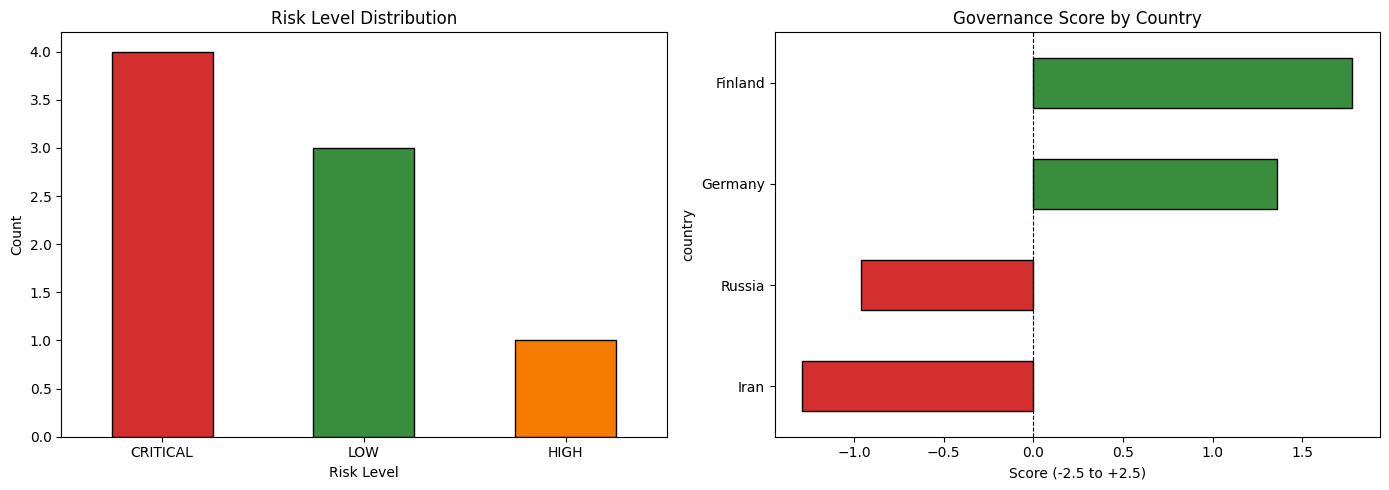

Results exported to /Users/mianoll-jones/Downloads/eurasian-risk-screener/screening_results.csv


In [11]:
# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk level distribution
risk_counts = results['risk_level'].value_counts()
colors = {'CRITICAL': '#d32f2f', 'HIGH': '#f57c00', 'MEDIUM': '#fbc02d', 'LOW': '#388e3c'}
risk_counts.plot.bar(
    ax=axes[0],
    color=[colors.get(r, 'gray') for r in risk_counts.index],
    edgecolor='black'
)
axes[0].set_title('Risk Level Distribution')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Governance scores by country
gov_by_country = results.drop_duplicates('country').set_index('country')['governance_score'].sort_values()
gov_by_country.plot.barh(
    ax=axes[1],
    color=['#d32f2f' if x < -0.5 else '#f57c00' if x < 0.5 else '#388e3c' for x in gov_by_country],
    edgecolor='black'
)
axes[1].set_title('Governance Score by Country')
axes[1].set_xlabel('Score (-2.5 to +2.5)')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(folder, 'risk_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Export results
output_path = os.path.join(folder, 'screening_results.csv')
results.to_csv(output_path, index=False)
print(f"Results exported to {output_path}")